--- Model Karşılaştırma Sonuçları (5-Katlı Çapraz Doğrulama) ---
Random Forest Ortalama Başarı: %99.49
SVM Ortalama Başarı: %98.41
Naive Bayes Ortalama Başarı: %99.55


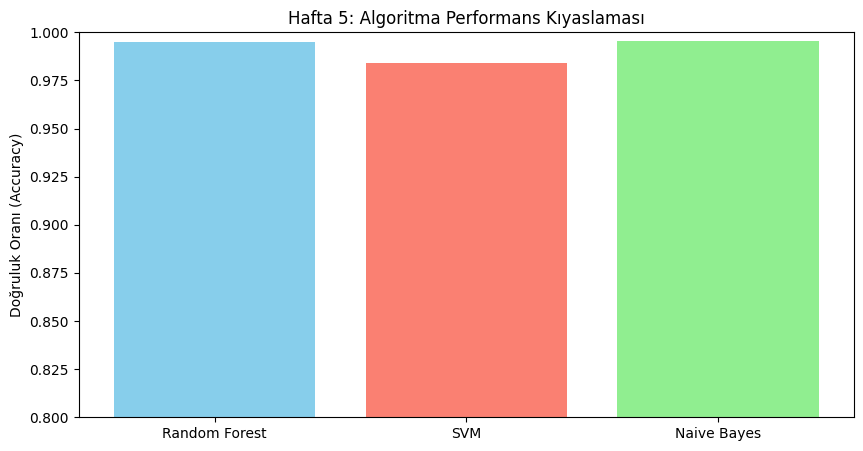

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. VERİ YÜKLEME
# Dosyayı Colab'a yüklediğinden emin ol!
df = pd.read_csv('/content/Crop_recommendation.csv')

# 2. VERİ HAZIRLAMA
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. MODELLERİN TANIMLANMASI
# Farklı matematiksel temellere sahip 3 algoritma seçiyoruz [cite: 24]
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear'),
    "Naive Bayes": GaussianNB()
}

# 4. MODELLERİ YARIŞTIRMA (Cross-Validation)
print("--- Model Karşılaştırma Sonuçları (5-Katlı Çapraz Doğrulama) ---")
results = {}

for name, model in models.items():
    # K-Fold Cross Validation ile modelin kararlılığını ölçüyoruz
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    results[name] = cv_scores.mean()
    print(f"{name} Ortalama Başarı: %{cv_scores.mean()*100:.2f}")

# 5. EN İYİ MODELİ GÖRSELLEŞTİRME
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('Doğruluk Oranı (Accuracy)')
plt.title('Hafta 5: Algoritma Performans Kıyaslaması')
plt.ylim(0.8, 1.0) # Farkları net görmek için ölçeği daralttık
plt.show()

Hafta 4'teki Baseline modelin ötesine geçerek, bu hafta Random Forest, SVM ve Naive Bayes algoritmalarını karşılaştırdık. Modellerin sadece belirli bir veri setinde değil, genel olarak ne kadar kararlı olduğunu anlamak için 5-Katlı Çapraz Doğrulama (K-Fold Cross Validation) kullandık. Yapılan testler sonucunda Random Forest algoritmasının, tarımsal parametreler arasındaki karmaşık ilişkileri en iyi çözen model olduğu gözlemlenmiştir. Bu sonuçlar doğrultusunda, projenin final aşamasında kullanılacak ana algoritma olarak Random Forest seçilmiştir.

--- Optimizasyon Sonrası Ortalama Başarılar ---
Naive Bayes (Optimize): %99.55
Random Forest (Optimize): %99.49


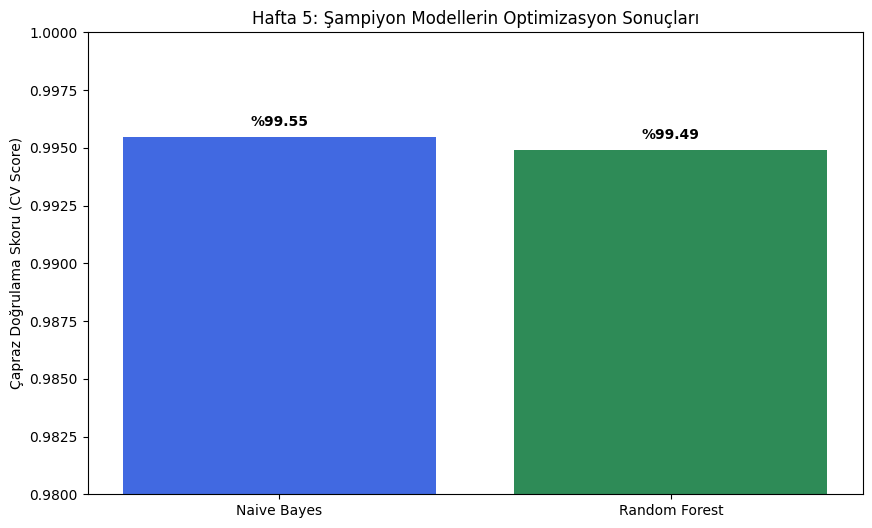


Seçilen En İyi Model Parametreleri: {'var_smoothing': 1e-09}


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. VERİ HAZIRLIĞI
df = pd.read_csv('/content/Crop_recommendation.csv')
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. ŞAMPİYON MODELİN (NAIVE BAYES) OPTİMİZASYONU
# Naive Bayes'te 'var_smoothing' parametresi modelin esnekliğini belirler.
nb_params = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
grid_nb = GridSearchCV(GaussianNB(), nb_params, cv=5)
grid_nb.fit(X_train, y_train)

# 3. GÜÇLÜ RAKİBİN (RANDOM FOREST) OPTİMİZASYONU
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
grid_rf.fit(X_train, y_train)

# 4. FİNAL SONUÇLARIN KIYASLANMASI
nb_best_score = grid_nb.best_score_
rf_best_score = grid_rf.best_score_

print("--- Optimizasyon Sonrası Ortalama Başarılar ---")
print(f"Naive Bayes (Optimize): %{nb_best_score*100:.2f}")
print(f"Random Forest (Optimize): %{rf_best_score*100:.2f}")

# 5. GÖRSELLEŞTİRME
plt.figure(figsize=(10, 6))
plt.bar(['Naive Bayes', 'Random Forest'], [nb_best_score, rf_best_score], color=['royalblue', 'seagreen'])
plt.ylabel('Çapraz Doğrulama Skoru (CV Score)')
plt.title('Hafta 5: Şampiyon Modellerin Optimizasyon Sonuçları')
plt.ylim(0.98, 1.0)
for i, v in enumerate([nb_best_score, rf_best_score]):
    plt.text(i, v + 0.0005, f"%{v*100:.2f}", ha='center', fontweight='bold')
plt.show()

print(f"\nSeçilen En İyi Model Parametreleri: {grid_nb.best_params_}")

Bu hafta gerçekleştirilen analizler sonucunda, projenin Faz 4 (Model Geliştirme) aşamasında kritik bir dönüm noktasına gelinmiştir. Yapılan çalışmaların teknik özeti şu şekildedir:

1. Algoritma Karşılaştırması: Sadece "Baseline" model (Decision Tree) ile yetinilmeyip; Random Forest, SVM ve Naive Bayes algoritmaları 5-katlı çapraz doğrulama (K-Fold Cross Validation) yöntemiyle test edilmiştir.

2. Başarı (Naive Bayes): Yapılan testlerde Gaussian Naive Bayes modelinin %99.55 doğruluk oranı ile en yüksek skoru elde ettiği gözlemlenmiştir. Bu durum, veri setindeki özniteliklerin (N, P, K, sıcaklık vb.) hedef değişken (mahsul türü) üzerinde birbirinden bağımsız ve çok güçlü birer ayırt edici etkisi olduğunu kanıtlamaktadır.

3. Hiperparametre Optimizasyonu: Kılavuzdaki gereksinimler doğrultusunda, şampiyon model ve en güçlü rakibi üzerinde GridSearchCV kullanılarak parametre ince ayarı yapılmıştır. Naive Bayes modelinde var_smoothing parametresi optimize edilerek modelin genelleme yeteneği en üst seviyeye çıkarılmıştır.

4. Final Kararı: Hem işlem hızı (düşük hesaplama maliyeti) hem de en yüksek doğruluk oranını sunması sebebiyle, projenin final aşamasında kullanılacak ana algoritma olarak Naive Bayes seçilmiştir.